In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import time
import pinocchio as pin
from pinocchio.visualize import MeshcatVisualizer
from meshcat.transformations import translation_matrix, rotation_matrix
from meshcat.geometry import Box, MeshPhongMaterial, Cylinder

### Visualization

In [2]:
# specify a path the the urdf files and meshes
urdf_model_path = "diffdrive.urdf"
mesh_dir = ""

# load the robot using pinocchio
robot = pin.RobotWrapper.BuildFromURDF(urdf_model_path, mesh_dir)

# vizualize the robot using meshcat
viz = MeshcatVisualizer(robot.model, robot.collision_model, robot.visual_model)
viz.initViewer(loadModel=True)

def show_robot(x,y,theta):
    quat = pin.Quaternion(pin.utils.rotate('z', theta)).coeffs()
    pos = np.array([x,y,0.1])

    viz.display(np.append(pos,quat))

You can open the visualizer by visiting the following URL:
http://127.0.0.1:7001/static/


In [3]:
# Add a floor
# Add floor material
material_floor = MeshPhongMaterial()
material_floor.color = int(200) * 256**2 + int(200) * 256 + int(200)
# Add a floor
viz.viewer["/Floor"].set_object(
    Box([10, 10, 0.01]),
    material_floor
)
viz.viewer["/Floor"].set_transform(
    translation_matrix([0, 0, -0.005])
)

# Add obstacle material
material_obstacle = MeshPhongMaterial()
material_obstacle.color = int(100) * 256**2 + int(100) * 256 + int(100)

# Randomly generate 30 obstacle positions within a defined range
np.random.seed(6) #6
obstacle_positions = [
    np.array([np.random.uniform(-4.8, 4.8), np.random.uniform(-4.8, 4.8), 0.5])
    for _ in range(10)
]

# add cylinders for each obstacle
for i, pos in enumerate(obstacle_positions):
    viz.viewer[f"/Obstacle_{i}"].set_object(
        Cylinder(1, 0.2), material_obstacle
    )
    T_world_obs = translation_matrix(pos)
    T_world_obs[:3, :3] = pin.utils.rotate('x', np.pi / 2)
    viz.viewer[f"/Obstacle_{i}"].set_transform(
        T_world_obs
    )
for i, pos in enumerate(obstacle_positions[::2]):
    # Connect a wall (box) between the two obstacles
    wall_length = np.linalg.norm(obstacle_positions[2*i][:2] - obstacle_positions[2*i+1][:2])
    wall_width = 0.4
    wall_height = 1.0
    wall_material = MeshPhongMaterial()
    wall_material.color = int(100) * 256**2 + int(100) * 256 + int(100)

    wall_position = (obstacle_positions[2*i][:2] + obstacle_positions[2*i+1][:2]) / 2

    viz.viewer[f"/Wall_Obstacle_{i}"].set_object(
        Box([wall_length, wall_width, wall_height]), wall_material
    )
    # Set the wall rotation to align with the line between the two obstacles
    angle = np.arctan2(
        obstacle_positions[2*i+1][1] - obstacle_positions[2*i][1],
        obstacle_positions[2*i+1][0] - obstacle_positions[2*i][0]
    )
    viz.viewer[f"/Wall_Obstacle_{i}"].set_transform(
        translation_matrix([wall_position[0], wall_position[1], wall_height / 2]) @
        rotation_matrix(angle, [0, 0, 1])
    )

# Add walls around the floor
wall_thickness = 0.1
wall_height = 1.0

# Left wall
viz.viewer["/Wall_Left"].set_object(Box([wall_thickness, 10, wall_height]))
viz.viewer["/Wall_Left"].set_transform(
    translation_matrix([-5 - wall_thickness / 2, 0, wall_height / 2])
)

# Right wall
viz.viewer["/Wall_Right"].set_object(Box([wall_thickness, 10, wall_height]))
viz.viewer["/Wall_Right"].set_transform(
    translation_matrix([5 + wall_thickness / 2, 0, wall_height / 2])
)

# Front wall
viz.viewer["/Wall_Front"].set_object(Box([10, wall_thickness, wall_height]))
viz.viewer["/Wall_Front"].set_transform(
    translation_matrix([0, 5 + wall_thickness / 2, wall_height / 2])
)

# Back wall
viz.viewer["/Wall_Back"].set_object(Box([10, wall_thickness, wall_height]))
viz.viewer["/Wall_Back"].set_transform(
    translation_matrix([0, -5 - wall_thickness / 2, wall_height / 2])
)

# can you add a tower in each corner of the walls?
tower_height = 1.5
tower_radius = 0.3
tower_material = MeshPhongMaterial()
tower_material.color = int(100) * 256**2 + int(100) * 256 + int(100)

tower_positions = [
    np.array([-5 - wall_thickness / 2, 5 + wall_thickness / 2, tower_height / 2]),
    np.array([5 + wall_thickness / 2, 5 + wall_thickness / 2, tower_height / 2]),
    np.array([-5 - wall_thickness / 2, -5 - wall_thickness / 2, tower_height / 2]),
    np.array([5 + wall_thickness / 2, -5 - wall_thickness / 2, tower_height / 2])
]

for i, pos in enumerate(tower_positions):
    viz.viewer[f"/Tower_{i}"].set_object(
        Cylinder(tower_height, tower_radius), tower_material
    )
    T_world_tower = translation_matrix(pos)
    T_world_tower[:3, :3] = pin.utils.rotate('x', np.pi / 2)
    viz.viewer[f"/Tower_{i}"].set_transform(
        T_world_tower
    )

In [4]:
x,y,theta = 0,0,0
show_robot(x,y,theta)

### Simulation

In [5]:
# Define robot dynamics
def discrete_dynamics(state, control_input, dt, model_mismatch=False):
    """
    Update the robot's state based on its dynamics.

    Parameters:
    - state: Current state [x, y, theta]
    - control_input: Control input [linear_velocity, angular_velocity]
    - dt: Time step

    Returns:
    - Updated state [x, y, theta]
    """
    x, y, theta = state
    linear_velocity, angular_velocity = control_input
    if model_mismatch:
        # Small actuation disturbance on the control inputs.
        # NOTE: these std-devs must stay consistent with the EKF's
        # sigma_v / sigma_w, so that the filter's process noise Q matches
        # the disturbance that actually enters the system.
        linear_velocity  += np.random.normal(0, 0.1)
        angular_velocity += np.random.normal(0, 0.1)

    # Update state using differential drive kinematics
    x += linear_velocity * np.cos(theta) * dt
    y += linear_velocity * np.sin(theta) * dt
    theta += angular_velocity * dt

    # Normalize theta to keep it within [-pi, pi]
    theta = np.arctan2(np.sin(theta), np.cos(theta))

    return np.array([x, y, theta])


In [6]:
def simulation(controller):
    # Simulation parameters
    radius = 1.0  # Radius of the circle
    linear_velocity = 1.5  # Linear velocity (m/s)
    angular_velocity = -linear_velocity / radius  # Angular velocity (rad/s)
    dt = 0.01  # Time step (s)
    simulation_time = 5  # Total simulation time (s)
    sensor_noise_stddev = 0.03  # Standard deviation of sensor noise (m)

    # Initial robot position and orientation
    x, y, theta = 0.0, 0.0, 0.0  # Initial position (x, y) and orientation (theta)

    # Simulation loop
    for t in np.arange(0, simulation_time, dt):

        z = np.array([x,y]) + np.random.normal(0, sensor_noise_stddev, 2)  # Simulated sensor measurement with noise

        # calculate control inputs
        u,w = controller(x,y,theta,z)

        # Update robot position and orientation using differential drive kinematics
        x, y, theta = discrete_dynamics([x, y, theta], [u,w], dt, model_mismatch=True)

        # Normalize theta to keep it within [-pi, pi]
        theta = np.arctan2(np.sin(theta), np.cos(theta))

        # Display the robot in the visualization
        show_robot(x, y, theta)
        # Calculate and visualize distances to towers

        # Pause to simulate real-time visualization
        time.sleep(dt)

In [7]:
def controller(x,y,theta,z):
    return 2, -2

In [8]:
simulation(controller)

# 1.1 Local Planner
Optimization-based motion planner for the robot, ignoring obstacles

In [9]:
import casadi as ca
import numpy as np

def local_planner(start, goal, N=20, dt=0.2):
    opti = ca.Opti()

    X = opti.variable(3, N+1)
    U = opti.variable(2, N)

    # Cost function
    cost = 0
    for k in range(N):
        cost += 1.0 * U[0,k]**2 
        cost += 20.0 * U[1,k]**2 
        if k < N-1:
            cost += 10.0 * (U[1,k+1] - U[1,k])**2

    opti.minimize(cost)

    # Kinematics
    for k in range(N):
        x_next = X[0,k] + U[0,k] * ca.cos(X[2,k]) * dt
        y_next = X[1,k] + U[0,k] * ca.sin(X[2,k]) * dt
        t_next = X[2,k] + U[1,k] * dt
        opti.subject_to(X[0,k+1] == x_next)
        opti.subject_to(X[1,k+1] == y_next)
        opti.subject_to(X[2,k+1] == t_next)

    # Boundary conditions
    opti.subject_to(X[:,0] == start)
    opti.subject_to(X[:,N] == goal)

    # Constraints
    opti.subject_to(opti.bounded(0.0, U[0,:], 1.5))
    opti.subject_to(opti.bounded(-1.5, U[1,:], 1.5))

    # Initial guess
    opti.set_initial(X[0,:], np.linspace(start[0], goal[0], N+1))
    opti.set_initial(X[1,:], np.linspace(start[1], goal[1], N+1))
    
    # Interpolate theta over the shortest path
    theta_diff = np.arctan2(np.sin(goal[2] - start[2]), 
                            np.cos(goal[2] - start[2]))
    theta_init = np.array([start[2] + theta_diff * k/N for k in range(N+1)])
    opti.set_initial(X[2,:], theta_init)
    opti.set_initial(U, 0.1)

    # Solve
    opti.solver('ipopt', {'ipopt.print_level': 0, 'print_time': 0, 'ipopt.max_iter': 1000})
    
    try:
        sol = opti.solve()
        return sol.value(X), sol.value(U)
    except:
        return None, None

# 1.2 Collision Check
Python function checks if a solution found by the local planner is effectively collision-free

In [10]:
# Collision parameters
r_robot = 0.31
r_obstacle = 0.2
r_tower = 0.3
safety_margin = 0.08

# Cylinders + Towers as circles
obstacles_2d = []
for pos in obstacle_positions:
    obstacles_2d.append((pos[:2], r_obstacle))
for pos in tower_positions:
    obstacles_2d.append((pos[:2], r_tower))

# Outer walls as line segments
walls = [
    (np.array([-5.0, -5.0]), np.array([-5.0,  5.0])),
    (np.array([ 5.0, -5.0]), np.array([ 5.0,  5.0])),
    (np.array([-5.0,  5.0]), np.array([ 5.0,  5.0])),
    (np.array([-5.0, -5.0]), np.array([ 5.0, -5.0])),
]

# Connecting walls between cylinders
connection_walls = []
for i in range(len(obstacle_positions) // 2):
    p1 = obstacle_positions[2*i][:2]
    p2 = obstacle_positions[2*i+1][:2]
    connection_walls.append((p1, p2))

# Helper function (calculating the distance between the robot and the wall)
def point_to_segment_distance(point, seg_start, seg_end):
    seg = seg_end - seg_start
    t = np.dot(point - seg_start, seg) / np.dot(seg, seg)
    t = np.clip(t, 0, 1)
    closest = seg_start + t * seg
    return np.linalg.norm(point - closest)

In [11]:
def collision_check(X_path):
    for k in range(X_path.shape[1]):
        robot_pos = X_path[:2, k]
        
        # Cylinders and towers
        for obs_pos, obs_radius in obstacles_2d:
            abstand = np.linalg.norm(robot_pos - obs_pos)
            if abstand < r_robot + obs_radius + safety_margin:
                return False
        
        # Outer walls
        for wall_start, wall_end in walls:
            abstand = point_to_segment_distance(robot_pos, wall_start, wall_end)
            if abstand < r_robot + safety_margin:
                return False
        
        # Connecting walls between cylinders
        for wall_start, wall_end in connection_walls:
            abstand = point_to_segment_distance(robot_pos, wall_start, wall_end)
            wall_width = 0.2  # half of the width of the wall (wall_width=0.4 in original)
            if abstand < r_robot + wall_width + safety_margin:
                return False
    
    return True

# 1.3 Global Planner
Probabalistic roadmap (PRM) algorithm with local planner as subroutine

In [12]:
import heapq

def astar(graph, start, goal, samples):
    """A* shortest-path search over the PRM graph.

    The heuristic is the straight-line Euclidean distance in (x, y) from a node
    to the goal node. Since the edge weights are themselves Euclidean distances
    between sampled positions, this heuristic never overestimates the true
    remaining cost (it is admissible), so A* returns the same optimal path as
    Dijkstra while expanding fewer nodes.
    """
    def heuristic(node):
        return np.linalg.norm(samples[node][:2] - samples[goal][:2])

    g_score = {node: float('inf') for node in graph}
    g_score[start] = 0.0
    previous = {node: None for node in graph}

    # priority queue ordered by f = g + h ; (f, g, node)
    queue = [(heuristic(start), 0.0, start)]
    visited = set()

    while queue:
        f_current, g_current, current = heapq.heappop(queue)
        if current == goal:
            break
        if current in visited:
            continue
        visited.add(current)

        for neighbor, weight in graph[current]:
            tentative_g = g_current + weight
            if tentative_g < g_score[neighbor]:
                g_score[neighbor] = tentative_g
                previous[neighbor] = current
                f_neighbor = tentative_g + heuristic(neighbor)
                heapq.heappush(queue, (f_neighbor, tentative_g, neighbor))

    path = []
    current = goal
    while current is not None:
        path.append(current)
        current = previous[current]
    path.reverse()

    return path if path and path[0] == start else None


def prm(start, goal, n_samples=100, max_connections=5):
    # Step 1: Generate random points
    samples = [start]
    
    while len(samples) < n_samples + 1:
        x = np.random.uniform(-4.8, 4.8)
        y = np.random.uniform(-4.8, 4.8)
        theta = np.random.uniform(-np.pi, np.pi)
        point = np.array([x, y, theta])
        test_path = np.array([[x], [y], [theta]])
        if collision_check(test_path):
            samples.append(point)
    
    samples.append(goal)
    goal_idx = len(samples) - 1

    # Step 2: Build graph
    graph = {i: [] for i in range(len(samples))}
    saved_paths = {}
    
    print(f"Building graph with {len(samples)} nodes...")
    
    for i in range(len(samples)):
        distances = []
        for j in range(len(samples)):
            if i == j:
                continue
            dist = np.linalg.norm(samples[i][:2] - samples[j][:2])
            distances.append((dist, j))
        
        distances.sort()
        max_dist = 4.0
        connections = 0
        
        for dist, j in distances:
            if connections >= max_connections:
                break
            if dist > max_dist:
                break
            try:
                dx = samples[j][0] - samples[i][0]
                dy = samples[j][1] - samples[i][1]
                theta_ij = np.arctan2(dy, dx)

                if i == 0:
                    theta_start = start[2]
                else:
                    theta_start = theta_ij

                if j == goal_idx:
                    theta_goal = goal[2]
                else:
                    theta_goal = theta_ij

                start_i = np.array([samples[i][0], samples[i][1], theta_start])
                goal_j  = np.array([samples[j][0], samples[j][1], theta_goal])

                X_path, U_path = local_planner(start_i, goal_j)
                
                if X_path is None:
                    continue
                
                # Detect looping
                path_length = np.sum(np.linalg.norm(np.diff(X_path[:2,:], axis=1), axis=0))
                direct_dist = np.linalg.norm(goal_j[:2] - start_i[:2])
                if path_length > 3.0 * direct_dist:
                    continue
                
                if collision_check(X_path):
                    graph[i].append((j, dist))
                    graph[j].append((i, dist))
                    if (i,j) not in saved_paths:
                        saved_paths[(i,j)] = (X_path, U_path)
                        saved_paths[(j,i)] = (X_path[:, ::-1], U_path[:, ::-1])
                    connections += 1
            except:
                continue

    # Step 3: Find shortest path
    print("Searching for shortest path...")
    path_indices = astar(graph, 0, goal_idx, samples)
    
    if path_indices is None:
        print("No path found!")
        return None, None, None
    
    print(f"Path found! {len(path_indices)} waypoints.")

    # Step 4: Smooth theta
    print("Smoothing transitions...")
    smoothed_samples = [samples[i].copy() for i in path_indices]
    
    for k in range(1, len(path_indices) - 1):
        prev = smoothed_samples[k-1]
        next_p = smoothed_samples[k+1]
        dx = next_p[0] - prev[0]
        dy = next_p[1] - prev[1]
        smoothed_samples[k][2] = np.arctan2(dy, dx)
    
    smoothed_samples[0][2] = start[2]
    smoothed_samples[-1][2] = goal[2]

    # Step 5: Recalculate segments with normalized theta
    segments = []
    segments_U = []
    for k in range(len(smoothed_samples) - 1):
        s = smoothed_samples[k].copy()
        g = smoothed_samples[k+1].copy()
        
        # normalizing theta to pick the shortest path
        theta_diff = np.arctan2(np.sin(g[2] - s[2]), np.cos(g[2] - s[2]))
        g[2] = s[2] + theta_diff
        
        try:
            X_seg, U_seg = local_planner(s, g)
            
            if X_seg is None:
                raise Exception("local_planner returned None")
            
            # Looping erkennen
            path_length = np.sum(np.linalg.norm(np.diff(X_seg[:2,:], axis=1), axis=0))
            direct_dist = np.linalg.norm(g[:2] - s[:2])
            if path_length > 2.0 * direct_dist:
                raise Exception(f"Looping detected (ratio={path_length/direct_dist:.2f})")
            
            if collision_check(X_seg):
                segments.append(X_seg)
                segments_U.append(U_seg)
            else:
                raise Exception("Collision after smoothing")
                
        except Exception as e:
            print(f"Segment {k}: {e} → Using original")
            i = path_indices[k]
            j = path_indices[k+1]
            if (i,j) in saved_paths:
                X_seg, U_seg = saved_paths[(i,j)]
                segments.append(X_seg)
                segments_U.append(U_seg)
            else:
                print(f"No original for segment {k}! Path invalid.")
                return None, None, None

    # Step 6: Check continuity
    MAX_ANGLE_CHANGE = np.pi / 2
    path_continuous = True
    
    for k in range(len(segments) - 1):
        theta_end   = segments[k][2, -1]
        theta_start_next = segments[k+1][2, 0]
        angle_change = abs(np.arctan2(
            np.sin(theta_start_next - theta_end),
            np.cos(theta_start_next - theta_end)
        ))
        if angle_change > MAX_ANGLE_CHANGE:
            print(f"⚠️ Hairpin turn at segment {k}→{k+1}: {np.degrees(angle_change):.1f}°")
            path_continuous = False
    
    if not path_continuous:
        print("⚠️ Path not continuous! Please run again.")
        return None, None, None
    
    print("✅ Path continuous!")
    path = [smoothed_samples[k] for k in range(len(smoothed_samples))]
    return path, segments, segments_U

## PRM: entering START and GOAL points 
if ✅ Path continuous!, a path has been found, otherwise, run cell again

In [15]:
start = np.array([0.0, 0.0, 0.0])
goal  = np.array([4.0, -4.0, 1.0])

# Estimate arrival direction
dx = goal[0] - start[0]
dy = goal[1] - start[1]
theta_arrival = np.arctan2(dy, dx)
goal_adjusted = np.array([goal[0], goal[1], theta_arrival])

path, segments, segments_U = prm(start, goal_adjusted, n_samples=300, max_connections=15)

if path is None:
    print("No path found, run again!")
else:
    print(f"Path found with {len(path)} waypoints!")
    
    # Create X_ref and U_ref directly
    X_ref = np.hstack(segments)
    U_ref = np.hstack(segments_U)
    print(f"X_ref: {X_ref.shape[1]} steps")
    print(f"U_ref: {U_ref.shape[1]} steps")

Building graph with 302 nodes...
Searching for shortest path...
Path found! 12 waypoints.
Smoothing transitions...
✅ Path continuous!
Path found with 12 waypoints!
X_ref: 231 steps
U_ref: 220 steps


to visualize the found path:

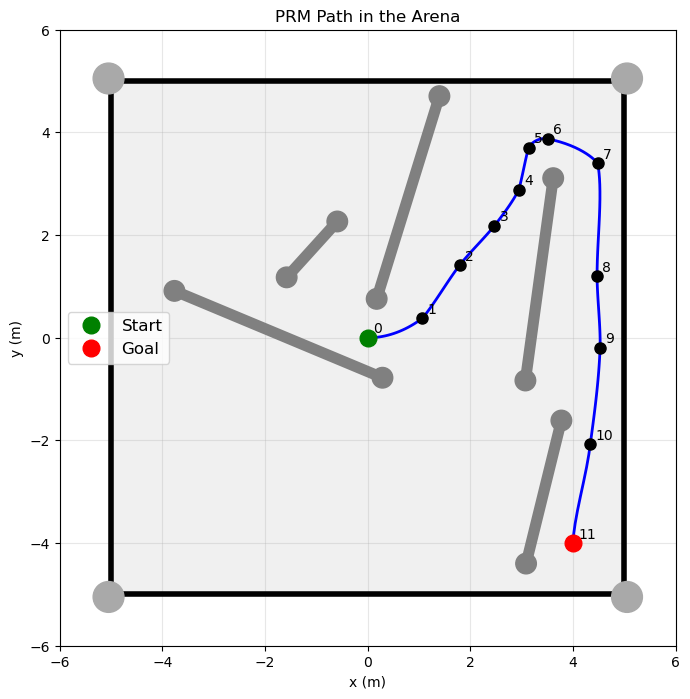

In [16]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.lines import Line2D

fig, ax = plt.subplots(1, 1, figsize=(8, 8))

# Inner area
inner = patches.Rectangle((-5, -5), 10, 10,
                           linewidth=0, facecolor='#f0f0f0')
ax.add_patch(inner)

# Outer walls
for wall_start, wall_end in walls:
    ax.plot([wall_start[0], wall_end[0]], 
            [wall_start[1], wall_end[1]], 
            'k-', linewidth=4, zorder=3)

# Connecting walls between cylinders
for wall_start, wall_end in connection_walls:
    ax.plot([wall_start[0], wall_end[0]], 
            [wall_start[1], wall_end[1]], 
            color='gray', linewidth=8, zorder=3)

# Obstacle cylinders
for pos, r in obstacles_2d[:10]:
    circle = plt.Circle(pos, r, color='gray', zorder=4)
    ax.add_patch(circle)

# Corner towers
for pos, r in obstacles_2d[10:14]:
    circle = plt.Circle(pos, r, color='darkgray', zorder=4)
    ax.add_patch(circle)

# Path segments
for X_segment in segments:
    ax.plot(X_segment[0,:], X_segment[1,:], 'b-', linewidth=2, zorder=5)

# Waypoints
for i, p in enumerate(path):
    ax.plot(p[0], p[1], 'ko', markersize=8, zorder=6)
    ax.annotate(f'{i}', (p[0]+0.1, p[1]+0.1), fontsize=10, zorder=7)

# Start and Goal
ax.plot(path[0][0], path[0][1], 'go', markersize=12, label='Start', zorder=7)
ax.plot(path[-1][0], path[-1][1], 'ro', markersize=12, label='Goal', zorder=7)

ax.set_xlim(-6, 6)
ax.set_ylim(-6, 6)
ax.set_aspect('equal')
ax.grid(True, alpha=0.3)
ax.legend(fontsize=12)
ax.set_title('PRM Path in the Arena')
ax.set_xlabel('x (m)')
ax.set_ylabel('y (m)')
plt.show()

# 2+3 Controller and Estimator

In [17]:
class EKF:

    def __init__(self, sigma_v=0.1, sigma_w=0.1, sigma_gps=0.03):
        # State estimate [x, y, theta]
        self.x = np.array([0.0, 0.0, 0.0])

        # Initial state covariance (we usually start from a known pose,
        # so this is fairly small).
        self.P = np.diag([0.1, 0.1, 0.1])

        # Std-devs of the actuation noise (must match discrete_dynamics).
        self.sigma_v = sigma_v
        self.sigma_w = sigma_w

        # GPS measurement noise on (x, y).
        self.R = np.diag([sigma_gps**2, sigma_gps**2])

        # Measurement matrix: GPS observes x and y, but not theta.
        self.H = np.array([[1.0, 0.0, 0.0],
                           [0.0, 1.0, 0.0]])

    def predict(self, u, dt):
        v, w = u
        theta = self.x[2]

        # Propagate the state with the nominal (noise-free) kinematics.
        self.x = discrete_dynamics(self.x, u, dt)

        # State Jacobian  F = df/dx
        F = np.array([
            [1.0, 0.0, -v * np.sin(theta) * dt],
            [0.0, 1.0,  v * np.cos(theta) * dt],
            [0.0, 0.0,  1.0]
        ])

        # Control Jacobian  B = df/du  (maps actuation noise into the state)
        B = np.array([
            [np.cos(theta) * dt, 0.0],
            [np.sin(theta) * dt, 0.0],
            [0.0,                dt ]
        ])

        # Process noise derived from the control-channel disturbance.
        M = np.diag([self.sigma_v**2, self.sigma_w**2])
        Q = B @ M @ B.T

        # Covariance prediction.
        self.P = F @ self.P @ F.T + Q

    def update(self, z):
        # Innovation: difference between GPS measurement and prediction.
        y = z - self.H @ self.x

        # Innovation covariance and Kalman gain.
        S = self.H @ self.P @ self.H.T + self.R
        K = self.P @ self.H.T @ np.linalg.inv(S)

        # State and covariance update.
        self.x = self.x + K @ y
        self.P = (np.eye(3) - K @ self.H) @ self.P

        # Keep theta within [-pi, pi].
        self.x[2] = np.arctan2(np.sin(self.x[2]), np.cos(self.x[2]))

    def get_estimate(self):
        return self.x


In [18]:
def get_reference(x, y, lookahead_dist=0.3, search_window=150):
    N = X_ref.shape[1]

    # persistent progress index (see get_reference.idx reset in simulation())
    i0 = getattr(get_reference, "idx", 0)

    # --- nearest reference point, searched ONLY forward from i0 ---
    hi = min(i0 + search_window, N)
    seg = X_ref[:2, i0:hi]
    d2 = (seg[0] - x) ** 2 + (seg[1] - y) ** 2
    closest_idx = i0 + int(np.argmin(d2))

    # monotonic: progress index can only advance, never go back
    get_reference.idx = max(i0, closest_idx)
    closest_idx = get_reference.idx

    # --- place the carrot a fixed arc-length ahead of the nearest point ---
    target_idx = closest_idx
    acc = 0.0
    while target_idx < N - 1 and acc < lookahead_dist:
        acc += np.linalg.norm(X_ref[:2, target_idx + 1] - X_ref[:2, target_idx])
        target_idx += 1

    ref   = X_ref[:, target_idx]
    u_ref = U_ref[:, min(target_idx, U_ref.shape[1] - 1)]
    return ref, u_ref


In [19]:
def controller(x, y, theta, z, step):
    k1 = 2.0 #1
    k2 = 1.0 #3
    k3 = 2.0 #2

    ref, u_ref = get_reference(x, y)
    x_ref  = ref[0]
    y_ref  = ref[1]
    th_ref = ref[2]
    v_ref  = u_ref[0]
    w_ref  = u_ref[1]

    e_x = x_ref - x
    e_y = y_ref - y
    e_theta = th_ref - theta
    e_theta = np.arctan2(np.sin(e_theta), np.cos(e_theta))

    e_1 =  np.cos(theta) * e_x + np.sin(theta) * e_y
    e_2 = -np.sin(theta) * e_x + np.cos(theta) * e_y

    v = v_ref * np.cos(e_theta) + k1 * e_1
    w = w_ref + k2 * e_2 + k3 * np.sin(e_theta)

    v = np.clip(v, -2.0, 2.0)
    w = np.clip(w, -2.0, 2.0)

    return v, w

In [21]:
def simulation(controller, start, goal):
    dt = 0.01  # like original
    sensor_noise_stddev = 0.03
    x, y, theta = start
    
    ekf = EKF()
    ekf.x = np.array([start[0], start[1], start[2]])
    get_reference.idx = 0  # reset monotonic path-progress tracker
    
    total_steps = sum([U_seg.shape[1] for U_seg in segments_U])
    # more steps because dt is smaller
    max_steps = total_steps * 20 * 4
    step = 0
    last_pos = np.array([x, y])
    stuck_counter = 0
    pos_tol, theta_tol = 0.15, 0.10   # arrival: 15 cm position, ~6 deg heading

    while step < max_steps:
        z = np.array([x, y]) + np.random.normal(0, sensor_noise_stddev, 2)
        
        ekf.update(z)
        x_est, y_est, theta_est = ekf.get_estimate()
        
        dx, dy = goal[0] - x_est, goal[1] - y_est
        dist_to_goal = np.sqrt(dx**2 + dy**2)
        e_theta = np.arctan2(np.sin(goal[2] - theta_est), np.cos(goal[2] - theta_est))
        
        if dist_to_goal < pos_tol and abs(e_theta) < theta_tol:
            print(f"✅ Goal reached! dist={dist_to_goal:.2f} m, heading err={np.degrees(abs(e_theta)):.1f} deg")
            break

        curr_pos = np.array([x, y])
        if np.linalg.norm(curr_pos - last_pos) < 0.0001:
            stuck_counter += 1
        else:
            stuck_counter = 0
        last_pos = curr_pos
        
        if stuck_counter > 30:
            print(f"⚠️ Robot stuck at dist={dist_to_goal:.2f}m")
            break

        if dist_to_goal < 0.5:
            # Final approach: go-to-pose for a differential drive.
            if dist_to_goal > pos_tol:
                # Phase 1: turn to face the goal POINT, then drive in.
                # v depends on alignment with the goal direction (not on the
                # final heading), so it can no longer stall when mis-oriented.
                heading_to_goal = np.arctan2(dy, dx)
                e_h = np.arctan2(np.sin(heading_to_goal - theta_est),
                                 np.cos(heading_to_goal - theta_est))
                v_cmd = np.clip(0.6 * dist_to_goal * np.cos(e_h), 0.0, 0.4)
                w_cmd = np.clip(2.0 * e_h, -1.5, 1.5)
            else:
                # Phase 2: at the goal position -> rotate in place to goal heading.
                v_cmd = 0.0
                w_cmd = np.clip(2.0 * e_theta, -1.5, 1.5)
        else:
            v_cmd, w_cmd = controller(x_est, y_est, theta_est, z, step)
        
        x, y, theta = discrete_dynamics([x, y, theta], [v_cmd, w_cmd], dt, model_mismatch=True)
        theta = np.arctan2(np.sin(theta), np.cos(theta))
        
        ekf.predict([v_cmd, w_cmd], dt)
        
        show_robot(x, y, theta)
        time.sleep(dt)
        step += 1

    if step >= max_steps:
        print("⚠️ Max steps reached.")

if "✅ Goal reached!", the simulation has ended successfully

In [22]:
simulation(controller, start, goal_adjusted)

✅ Goal reached! dist=0.15 m, heading err=5.7 deg
